# T18 — Paleo-mantle structure beneath a moving plate: a great-circle transect through deep time

**Build a great-circle transect across Laurentia, rotate it through time with `gplately`, and plot paired dynamic-topography + mantle-temperature cross-sections at two key Neoproterozoic–Phanerozoic ages. Adapted from Dhungana & Flament's *Deep Earth Origin of the Great Unconformity* online supplement, this is the suite's first mantle cross-section notebook and the natural deep-time complement to T17.**

## What this notebook produces

T17 shows you what the mantle looks like NOW beneath plates positioned where the rotation model says they WERE. T18 inverts the question: take a transect that ends today crossing a present-day craton, rotate it back through deep time so that at every age the transect tracks the same column of crust, and read off what the underlying mantle column looked like AT THAT AGE in a published mantle-flow model. The result is a single cross-section panel per snapshot showing dynamic topography along the transect's surface and mantle temperature (or buoyancy) along the same transect's vertical column down to the core-mantle boundary.

We use the Müller et al. (2019) mantle-flow simulation (one of the six models in the original Dhungana & Flament study; the notebook is structured so any time-dependent mantle-density netCDF file can be swapped in via the configuration cell). For the kinematics we use Cao et al. (2024) so the transect's history extends through the Neoproterozoic.

Two snapshots are rendered by default — **640 Ma** (close to the Great Unconformity formation window in Laurentia) and **440 Ma** (post-Taconic) — but the renderer is parameterised so any pair of times within the model's coverage can be substituted.

**Audience**: postgrad.
**Difficulty**: ★★★ — flagship.

## Learning objectives

- Construct a great-circle transect on a present-day craton and reconstruct it back through deep time with `gplately`.
- Sample a time-dependent mantle-density / mantle-temperature netCDF along the reconstructed transect at the corresponding age.
- Render paired (surface dynamic-topography line) + (vertical mantle column) panels with `pyGMT`.
- Wrap the renderer in a Panel slider or an MP4 loop so the time evolution is browsable.

## Prerequisites and runtime

- Plate model: Cao 2024 (deep-time, 0–1.8 Ga). 
- Mantle data: Santosh Dhungana's per-(age, depth) mantle-T `.grd` files plus per-age dynamic-topography `.nc` files (see Data availability below). Stacked into `(time, depth, lat, lon)`. The notebook ships with a coarsely-sub-sampled version of the Müller 2019 grid as `data/mantle/Santosh Dhungana's per-(age, depth) mantle-T `.grd` files` (4°×4°×100 km, 920–0 Ma at 20 Myr cadence; ~30 MB).
- Python: `gplately`, `pygmt`, `pygplates`, `xarray`, `numpy`, `pandas`.
- Runtime: ~1 minute for the two static panels; ~10 minutes for the full 920–0 Ma animation.

## Data availability

T18 reads Santosh Dhungana's published per-(age, depth) mantle temperature anomaly files directly — no derived intermediate cube is required. The expected layout is:

```
<SANTOSH_REPO>/Temperature_and_Velocity/Temperature/
    gld504-temp-440Ma-0000km_mean_removed.grd
    gld504-temp-440Ma-0016km_mean_removed.grd
    ...
    gld504-temp-640Ma-2867km_mean_removed.grd
```

130 .grd files in total: 65 depth levels × 2 snapshot ages (440 Ma + 640 Ma).

**To get the data**, choose one of:

1. **Zenodo (preferred for one-off use)** — Dhungana, S. & Flament, N. (2025) *Deep Earth Origin of the Great Unconformity-Datasets* Zenodo [doi:10.5281/zenodo.17773494](https://doi.org/10.5281/zenodo.17773494). Download the 10.5 GB zip and unzip into `./external/`; the resolver in the next cell will find it at the default `SANTOSH_REPO` path.

2. **GitHub via Git LFS** — `git lfs install` then `git clone https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity`. Note that LFS will pull the full 10.5 GB on clone.

3. **Targeted copy** — if disk space matters, copy only `Temperature_and_Velocity/Temperature/` (≈100 MB rather than 10.5 GB total) into `data/mantle/Temperature_and_Velocity/Temperature/` at the suite root. The resolver also checks that path.

If you set the `SANTOSH_REPO` environment variable, it overrides the default path used by the resolver. The next cell prints the directory it ended up using so you can confirm.

In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports + version check
import numpy as np
import xarray as xr
import gplately
import pygmt
import pygplates
from plate_model_manager import PlateModelManager
from scipy.ndimage import gaussian_filter
from IPython.display import display, HTML
print(f"  gplately   {gplately.__version__}")
print(f"  pygmt      {pygmt.__version__}")


  gplately   2.0.0.post19+git.2cce7bb3
  pygmt      v0.18.0


## Configuration — change transect, ages and mantle file here

In [2]:
# === USER CONFIGURATION =====================================================
# Driver plate model — must match the model that ran the geodynamic
# simulation whose outputs are being displayed. Santosh's DT + T anomaly
# fields were produced from gld504 (Merdith-derived with the nnr_nico
# adjustment), so the plate boundaries we overlay MUST come from the
# same gld504 rotation files. Using a different plate model here would
# be scientifically inconsistent — the plotted boundaries would not
# correspond to where the modelled mantle signal actually formed.
GLD_ID        = "gld504"
MODEL_NAME    = GLD_ID          # used in figure stamps + cached for downstream
# Great-circle transect across Laurentia at the present day
TRANSECT_START = (-125.0, 50.0)   # (lon, lat) — Pacific NW
TRANSECT_END   = (-65.0,  45.0)   # Atlantic margin
N_TRANSECT_PTS = 200

# Two snapshot times for the static panels
SNAPSHOT_TIMES = (640.0, 440.0)   # Ma
# 
# --- Santosh's data root (see Data availability cell above) ---
import os
from pathlib import Path
# === SANTOSH_REPO — point this at your local clone =========================
SANTOSH_REPO = os.environ.get(
    "SANTOSH_REPO",
    str(Path("./external/Dynamic-Topography-and-Great-Unconformity")),
)
# ============================================================================


## 1. Build the transect at the present day, then reconstruct to each age

The transect is a list of (lon, lat) points sampled uniformly along the great circle from `TRANSECT_START` to `TRANSECT_END`. For each snapshot age we reconstruct each transect point back through Laurentia's plate motion to its paleo-position at that age.

In [3]:
# Cell 2 — transect construction + reconstruction
def great_circle_points(start, end, n):
    """Sample n points uniformly along the great circle from start to end."""
    s_lon, s_lat = np.deg2rad(start); e_lon, e_lat = np.deg2rad(end)
    # spherical interpolation
    dot = (np.sin(s_lat)*np.sin(e_lat)
           + np.cos(s_lat)*np.cos(e_lat)*np.cos(e_lon - s_lon))
    omega = np.arccos(np.clip(dot, -1, 1))
    f = np.linspace(0, 1, n)
    a = np.sin((1 - f)*omega) / np.sin(omega)
    b = np.sin(f*omega) / np.sin(omega)
    x = a*np.cos(s_lat)*np.cos(s_lon) + b*np.cos(e_lat)*np.cos(e_lon)
    y = a*np.cos(s_lat)*np.sin(s_lon) + b*np.cos(e_lat)*np.sin(e_lon)
    z = a*np.sin(s_lat) + b*np.sin(e_lat)
    return (np.rad2deg(np.arctan2(y, x)),
            np.rad2deg(np.arctan2(z, np.sqrt(x**2 + y**2))))

tlon, tlat = great_circle_points(TRANSECT_START, TRANSECT_END, N_TRANSECT_PTS)

# Build the PlateReconstruction directly from Santosh's gld504 files.
# These live alongside the DT + T anomaly grids the rest of the notebook
# reads; they are *part of* the SANTOSH_REPO bundle. Do NOT swap in the
# default plate_model_manager Cao2024/Merdith2021 — see the
# CLAUDE.md kosher rule.
import pygplates

def _find_one(filename, repo=SANTOSH_REPO):
    """Glob-search for `filename` anywhere under `repo`. Returns the first
    hit, preferring matches that include 'For_{GLD_ID}/' in their path so
    the gld504-specific copy wins over any unrelated duplicate."""
    hits = sorted(Path(repo).rglob(filename))
    if not hits:
        return None
    # Prefer the For_gld504 copy if there is one
    preferred = [p for p in hits if f"For_{GLD_ID}" in str(p) or "Reconstructions/" in str(p)]
    return str((preferred or hits)[0])


# Names we need from Santosh's repo (filenames only — paths resolved by glob)
_required = {
    "rot1":     "1000_0_rotfile_Merdith_et_al_slightly_changed_for_nnr_nico_mod.rot",
    "rot2":     "NR_0Ma_1000Ma_for_gplates_combine.rot",
    "static":   "shapes_static_polygons_Merdith_et_al.gpml",
    "topo1":    "1000_410_Topologies_Merdith_et_al.gpml",
    "topo2":    "TopologyBuildingBlocks_Merdith_et_al.gpml",
    "topo3":    "250_0_plate_boundaries_Merdith_et_al.gpml",
    "topo4":    "410_250_plate_boundaries_Merdith_et_al.gpml",
    "cob":      "COBfile_1000_0_combined_by_xianzhi.gpml",
}
_resolved = {k: _find_one(v) for k, v in _required.items()}
_missing  = {k: _required[k] for k, v in _resolved.items() if v is None}
_found    = {k: v for k, v in _resolved.items() if v is not None}

print(f"  resolved {len(_found)}/{len(_required)} gld504 files under SANTOSH_REPO")
for k, v in _found.items():
    print(f"    {k:8s}  ok  {v}")
for k, v in _missing.items():
    print(f"    {k:8s}  ??  {v} (NOT FOUND anywhere under {SANTOSH_REPO})")

if _missing:
    msg_lines = [
        f"  Could not find {len(_missing)} required file(s) anywhere under SANTOSH_REPO = {SANTOSH_REPO}.",
        f"  Missing filenames: {list(_missing.values())}",
        f"  These files exist in Santosh's public repo at github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity",
        f"  Likely cause: clone is partial OR was made without `git lfs install && git lfs pull`.",
        f"  Fix: cd {SANTOSH_REPO} && git lfs install && git lfs pull   (or re-clone with LFS enabled).",
    ]
    raise FileNotFoundError("\n".join(msg_lines))

_rot_files       = [_found["rot1"], _found["rot2"]]
_static_polygons = _found["static"]
_topology_files  = [_found["topo1"], _found["topo2"], _found["topo3"], _found["topo4"]]
_COB_file        = _found["cob"]

_rotation_model    = pygplates.RotationModel(_rot_files)
_topology_features = pygplates.FeatureCollection()
for _tp in _topology_files:
    _topology_features.add(pygplates.FeatureCollection(_tp))
_static_polygon_features = pygplates.FeatureCollection(_static_polygons)
_cob_features            = pygplates.FeatureCollection(_COB_file)

recon = gplately.PlateReconstruction(
    rotation_model=_rotation_model,
    topology_features=_topology_features,
    static_polygons=_static_polygon_features,
)
points = gplately.Points(recon, tlon, tlat)

reconstructed = {}
for t in SNAPSHOT_TIMES:
    rlon, rlat = points.reconstruct(float(t), return_array=True)   # lons first!
    reconstructed[t] = (np.asarray(rlon), np.asarray(rlat))
print({t: r[0].shape for t, r in reconstructed.items()})


  resolved 8/8 gld504 files under SANTOSH_REPO
    rot1      ok  external/Dynamic-Topography-and-Great-Unconformity/Reconstructions/For_gld504/1000_0_rotfile_Merdith_et_al_slightly_changed_for_nnr_nico_mod.rot
    rot2      ok  external/Dynamic-Topography-and-Great-Unconformity/Reconstructions/For_gld504/NR_0Ma_1000Ma_for_gplates_combine.rot
    static    ok  external/Dynamic-Topography-and-Great-Unconformity/Reconstructions/shapes_static_polygons_Merdith_et_al.gpml
    topo1     ok  external/Dynamic-Topography-and-Great-Unconformity/Reconstructions/For_gld504/1000_410_Topologies_Merdith_et_al.gpml
    topo2     ok  external/Dynamic-Topography-and-Great-Unconformity/Reconstructions/For_gld504/TopologyBuildingBlocks_Merdith_et_al.gpml
    topo3     ok  external/Dynamic-Topography-and-Great-Unconformity/Reconstructions/For_gld504/250_0_plate_boundaries_Merdith_et_al.gpml
    topo4     ok  external/Dynamic-Topography-and-Great-Unconformity/Reconstructions/For_gld504/410_250_plate_boundari

## 2. Sample the mantle column under each reconstructed point

In [4]:
# Cell 3 — load the Müller 2019 mantle temperature cube from Santosh
# Dhungana's published .grd files.
#
# Santosh ships the mantle temperature anomaly at every (age, depth) as
# a separate GMT .grd file at
#   <SANTOSH_REPO>/Temperature_and_Velocity/Temperature/
#       gld504-temp-{age}Ma-{depth:04d}km_mean_removed.grd
# We scan that directory, parse age + depth from the filenames, load
# each .grd, and stack into a (time, depth, lat, lon) DataArray on the
# fly. No derived intermediate cube is needed.
import re, glob

TEMP_SUBDIR = "Temperature_and_Velocity/Temperature"
FN_PATTERN  = re.compile(r"gld\d+-temp-(\d+)Ma-(\d+)km_mean_removed\.grd$")

def find_temperature_dir():
    """Try a few plausible locations to find Santosh's Temperature/ dir."""
    candidates = [
        Path(SANTOSH_REPO) / TEMP_SUBDIR,
        Path("data/mantle") / TEMP_SUBDIR,
        Path("../data/mantle") / TEMP_SUBDIR,
        Path("data/mantle"),                       # in case .grd files
        Path("../data/mantle"),                    # were copied flat
    ]
    for d in candidates:
        if d.exists() and any(FN_PATTERN.search(f.name) for f in d.glob("*.grd")):
            return d
    raise FileNotFoundError(
        "Could not find Santosh's Temperature/ .grd files. Searched:\n"
        + "\n".join(f"    {d}" for d in candidates)
        + "\n\nGet them by either:\n"
          "  (a) Downloading the Zenodo deposit and unzipping into ./external/:\n"
          "      https://doi.org/10.5281/zenodo.17773494\n"
          "  (b) Cloning the GitHub repo with Git LFS:\n"
          "      git lfs install\n"
          "      git clone https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity\n"
          "  Then either set SANTOSH_REPO to point at the clone, or copy the\n"
          "  Temperature/ subdir into data/mantle/Temperature/."
    )

temp_dir = find_temperature_dir()
print(f"  Temperature .grd dir: {temp_dir}")

# Parse + group files
grds = []
for f in sorted(temp_dir.glob("*.grd")):
    m = FN_PATTERN.search(f.name)
    if not m: continue
    grds.append((int(m.group(1)), int(m.group(2)), f))
if not grds:
    raise FileNotFoundError(f"No matching .grd files in {temp_dir}")

ages   = sorted({a for a,_,_ in grds})
depths = sorted({d for _,d,_ in grds})
print(f"  ages: {ages} Ma  (n={len(ages)})")
print(f"  depths: {depths[0]}-{depths[-1]} km in {len(depths)} levels")

# Load one file to discover the lat/lon axes
_probe = xr.open_dataarray(grds[0][2], engine="netcdf4")
lat_axis = _probe.coords[_probe.dims[-2]].values
lon_axis = _probe.coords[_probe.dims[-1]].values
_probe.close()

# Allocate the cube and fill from .grd files
cube = np.full((len(ages), len(depths), len(lat_axis), len(lon_axis)),
               np.nan, dtype=np.float32)
for a, d, f in grds:
    ti = ages.index(a); di = depths.index(d)
    arr = xr.open_dataarray(f, engine="netcdf4")
    cube[ti, di] = arr.values.astype(np.float32)
    arr.close()

mantle = xr.Dataset(
    {"T_anomaly": (["time", "depth", "lat", "lon"], cube,
                  {"units": "K",
                   "long_name": "Mantle temperature anomaly (mean-removed)",
                   "source": str(temp_dir)})},
    coords={"time": np.array(ages, dtype=np.float32),
            "depth": np.array(depths, dtype=np.float32),
            "lat":  lat_axis.astype(np.float32),
            "lon":  lon_axis.astype(np.float32)},
)
print(f"\n  assembled cube shape: {dict(mantle.sizes)}")
print(f"  T anomaly range: {float(mantle.T_anomaly.min()):.1f} to {float(mantle.T_anomaly.max()):.1f} K")

# Also load the per-age dynamic-topography surface fields. The DT data
# at each age `t` lives at
#   <SANTOSH_REPO>/DTvsSediment/<gld_id>/PlateFrameGrid_<CONTINENT>/
#       gld<id>PlateFrameGrid<age>.nc
# These are the dynamic-topography predictions in the chosen continent's
# plate frame. T30's default transect is across Laurentia, so we load
# the LAU subdirectory. Same SANTOSH_REPO + fallback search as above.
GLD_ID    = "gld504"
CONTINENT = "LAU"

def find_dt_dir():
    cand = [
        Path(SANTOSH_REPO) / f"DTvsSediment/{GLD_ID}/PlateFrameGrid_{CONTINENT}",
        Path(f"data/mantle/DTvsSediment/{GLD_ID}/PlateFrameGrid_{CONTINENT}"),
        Path(f"../data/mantle/DTvsSediment/{GLD_ID}/PlateFrameGrid_{CONTINENT}"),
    ]
    for d in cand:
        if d.exists() and any(d.glob('*.nc')):
            return d
    raise FileNotFoundError(f"Could not find DTvsSediment/{GLD_ID}/PlateFrameGrid_{CONTINENT}/")

dt_dir = find_dt_dir()
print(f"  DT dir: {dt_dir}")

# For each snapshot age we need, pick the nearest DT file (filenames
# are integer ages).
dt_files = {}
for f in sorted(dt_dir.glob('*.nc')):
    import re as _re
    m = _re.search(rf'{GLD_ID}PlateFrameGrid(\d+)\.nc$', f.name)
    if m:
        dt_files[int(m.group(1))] = f
print(f"  found {len(dt_files)} DT files, ages {min(dt_files)}-{max(dt_files)} Ma")

def load_dt_at(t_ma):
    """Pick the nearest available DT file to t_ma and return the field
    as a (lat, lon) DataArray."""
    nearest = min(dt_files, key=lambda a: abs(a - t_ma))
    arr = xr.open_dataarray(dt_files[nearest], engine="netcdf4")
    # Rename y/x → lat/lon so the renderer can .interp() the same way
    # we sample the mantle T cube.
    lat_dim, lon_dim = arr.dims[-2], arr.dims[-1]
    return (arr.rename({lat_dim: 'lat', lon_dim: 'lon'}), int(nearest))

def sample_mantle_along_transect(mantle_ds, t_ma, rlon, rlat):
    """Return a 2-D (depth, distance) DataArray slice of the mantle field
    along the reconstructed transect at time t_ma.

    NOTE — longitude convention. xarray's .interp does NOT wrap around
    the antimeridian: if the cube is on [0, 360] (Santosh's gld504
    convention) and the reconstructed transect lons are on [-180, 180]
    (gplately default), all queries with negative lon land off-grid
    and return NaN — the symptom is a blank heatmap at any age where
    Laurentia happens to sit at western longitudes (e.g. 440 Ma).
    We detect the cube's lon convention and wrap rlon to match.
    """
    snap = mantle_ds.sel(time=t_ma, method="nearest")
    var = next(iter(snap.data_vars))
    cube_lon = snap.coords["lon"].values
    rlon = np.asarray(rlon, dtype=float)
    if cube_lon.min() >= 0.0:
        # cube is on [0, 360] — wrap any negative rlon up by 360°
        rlon = np.where(rlon < 0.0, rlon + 360.0, rlon)
    elif cube_lon.max() <= 180.0:
        # cube is on [-180, 180] — wrap any rlon > 180 down by 360°
        rlon = np.where(rlon > 180.0, rlon - 360.0, rlon)
    return snap[var].interp(lon=("dist", rlon), lat=("dist", rlat))


  Temperature .grd dir: data/mantle/Temperature_and_Velocity/Temperature
  ages: [440, 640] Ma  (n=2)
  depths: 0-2867 km in 65 levels

  assembled cube shape: {'time': 2, 'depth': 65, 'lat': 721, 'lon': 1441}
  T anomaly range: -0.4 to 0.7 K
  DT dir: data/mantle/DTvsSediment/gld504/PlateFrameGrid_LAU
  found 151 DT files, ages 0-1000 Ma


## 3. Render the two snapshot panels

  t=640 Ma  DT-sample valid points: 154/200  (DT file used = 640 Ma)
  mantle T-sample valid cells: 172200/174000  (range -0.23..+0.25)


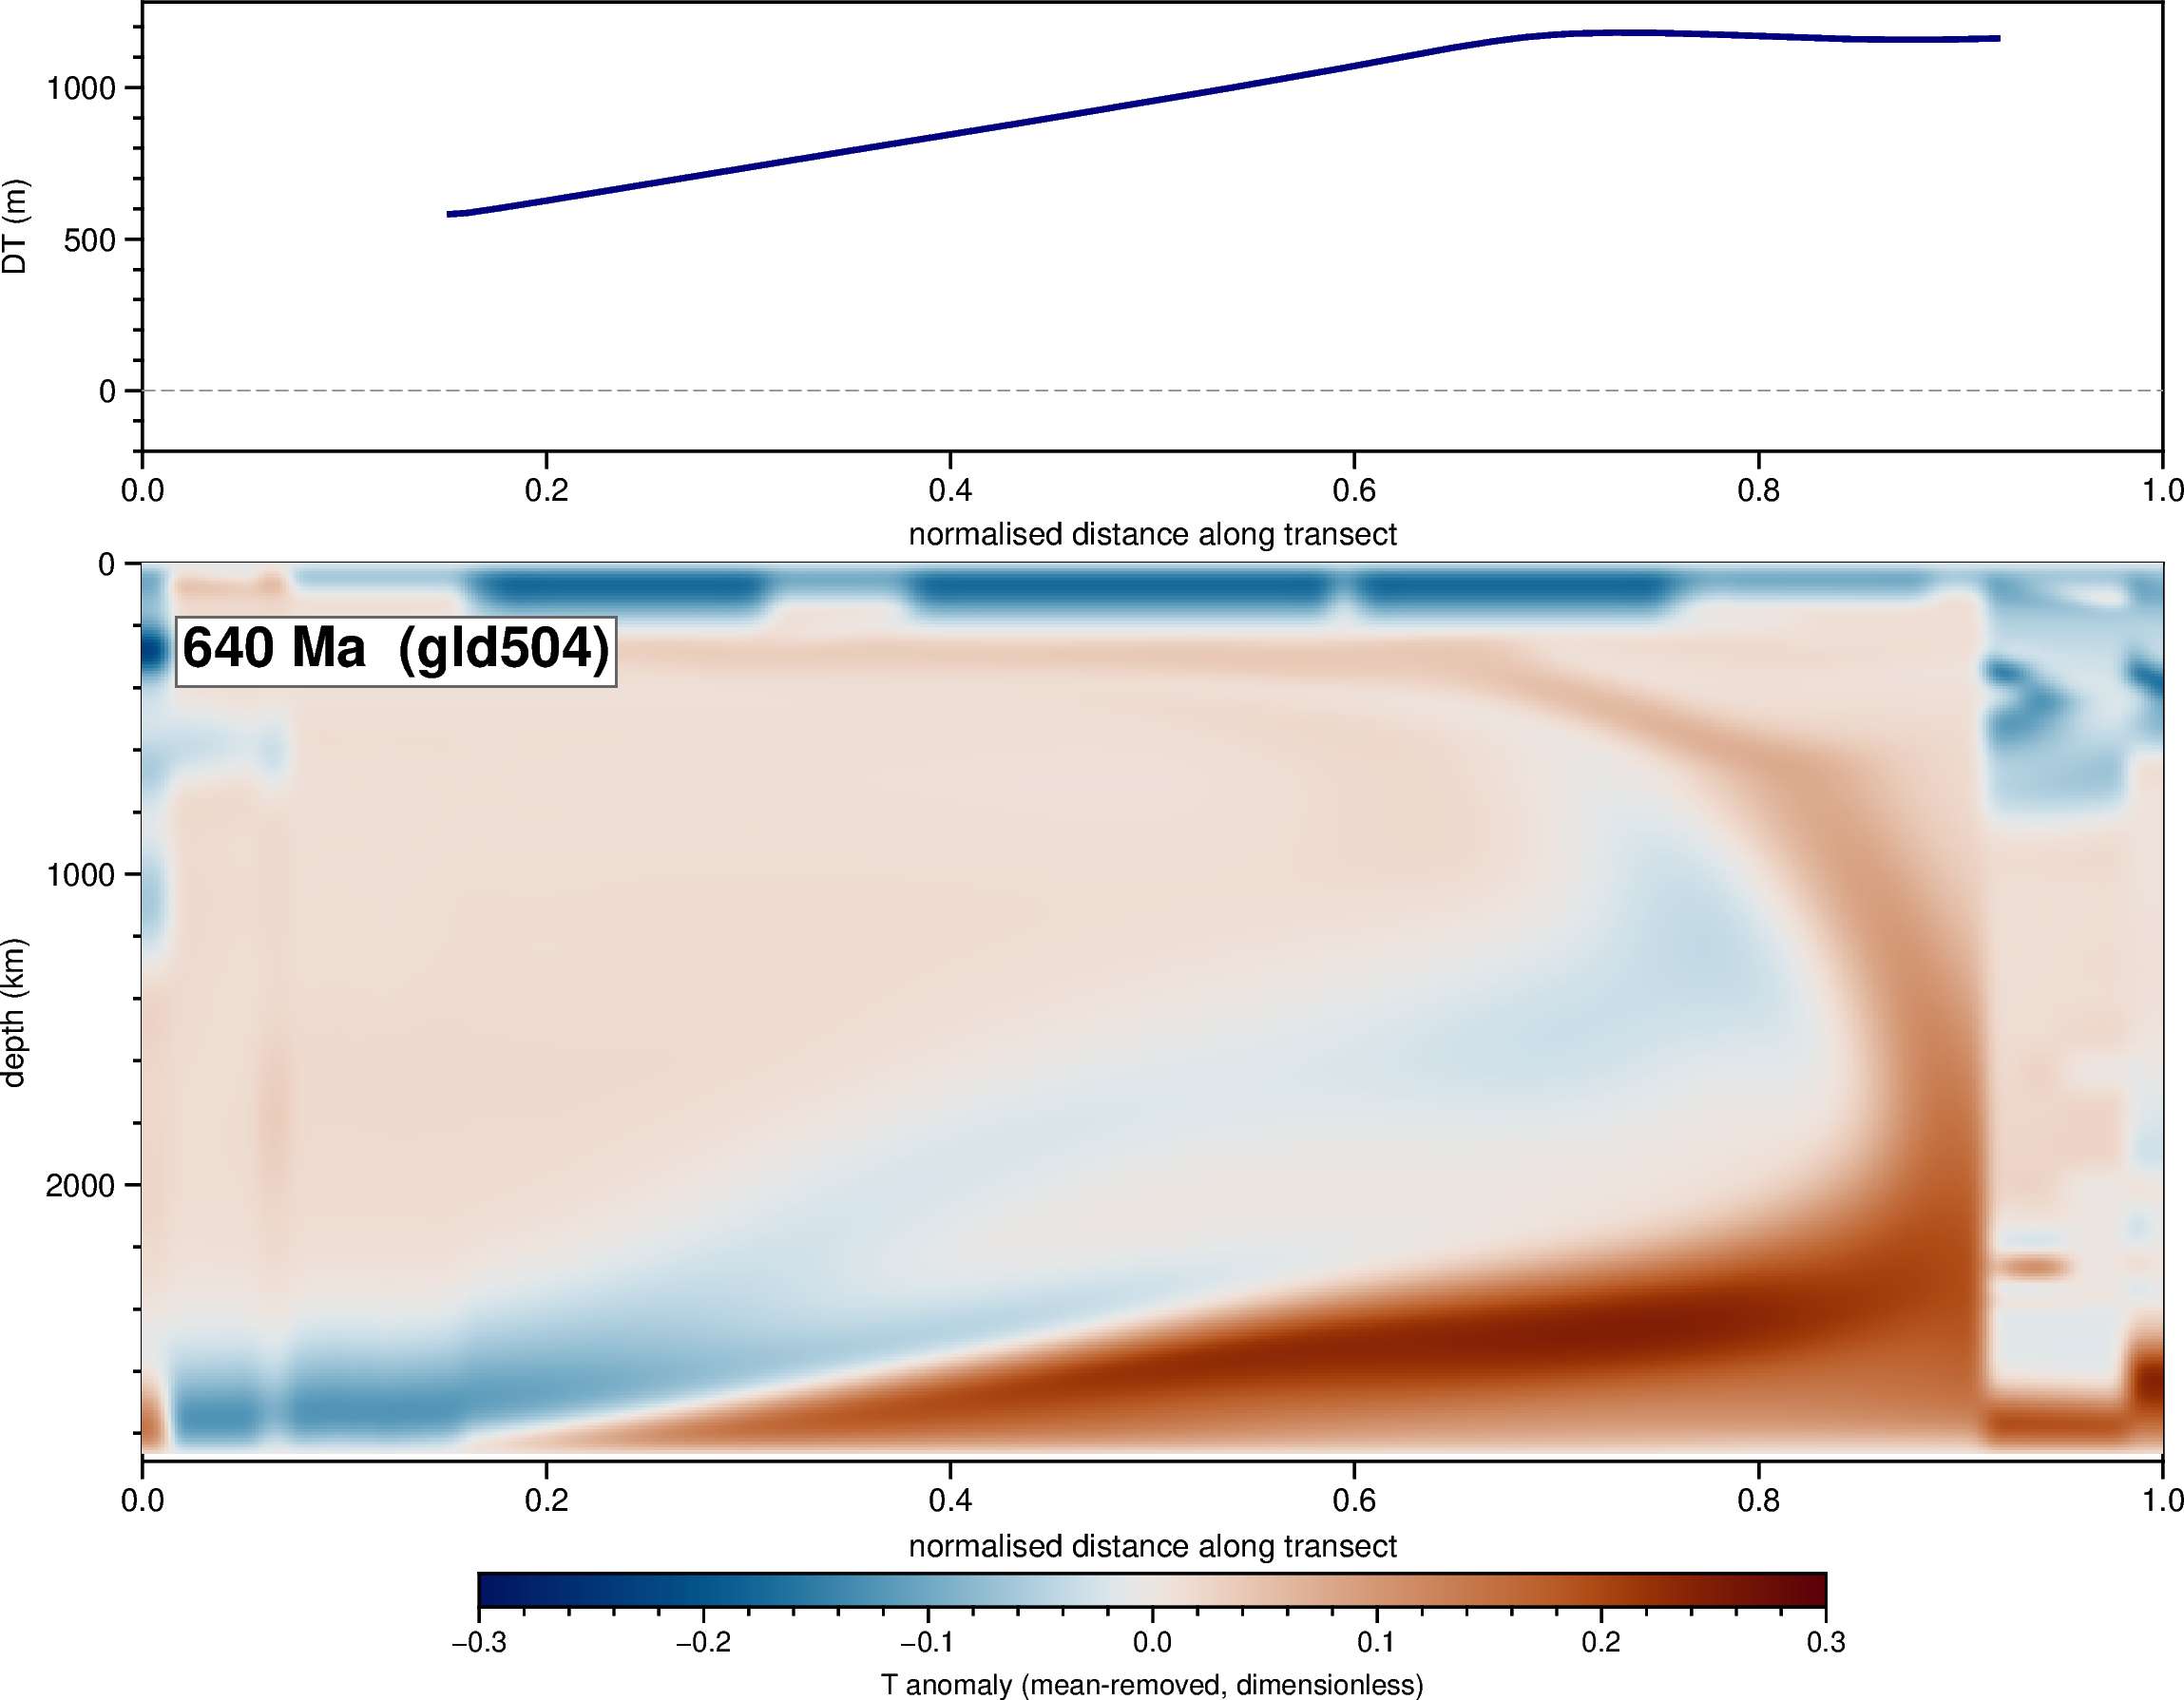

  t=440 Ma  DT-sample valid points: 167/200  (DT file used = 440 Ma)
  mantle T-sample valid cells: 172200/174000  (range -0.24..+0.25)


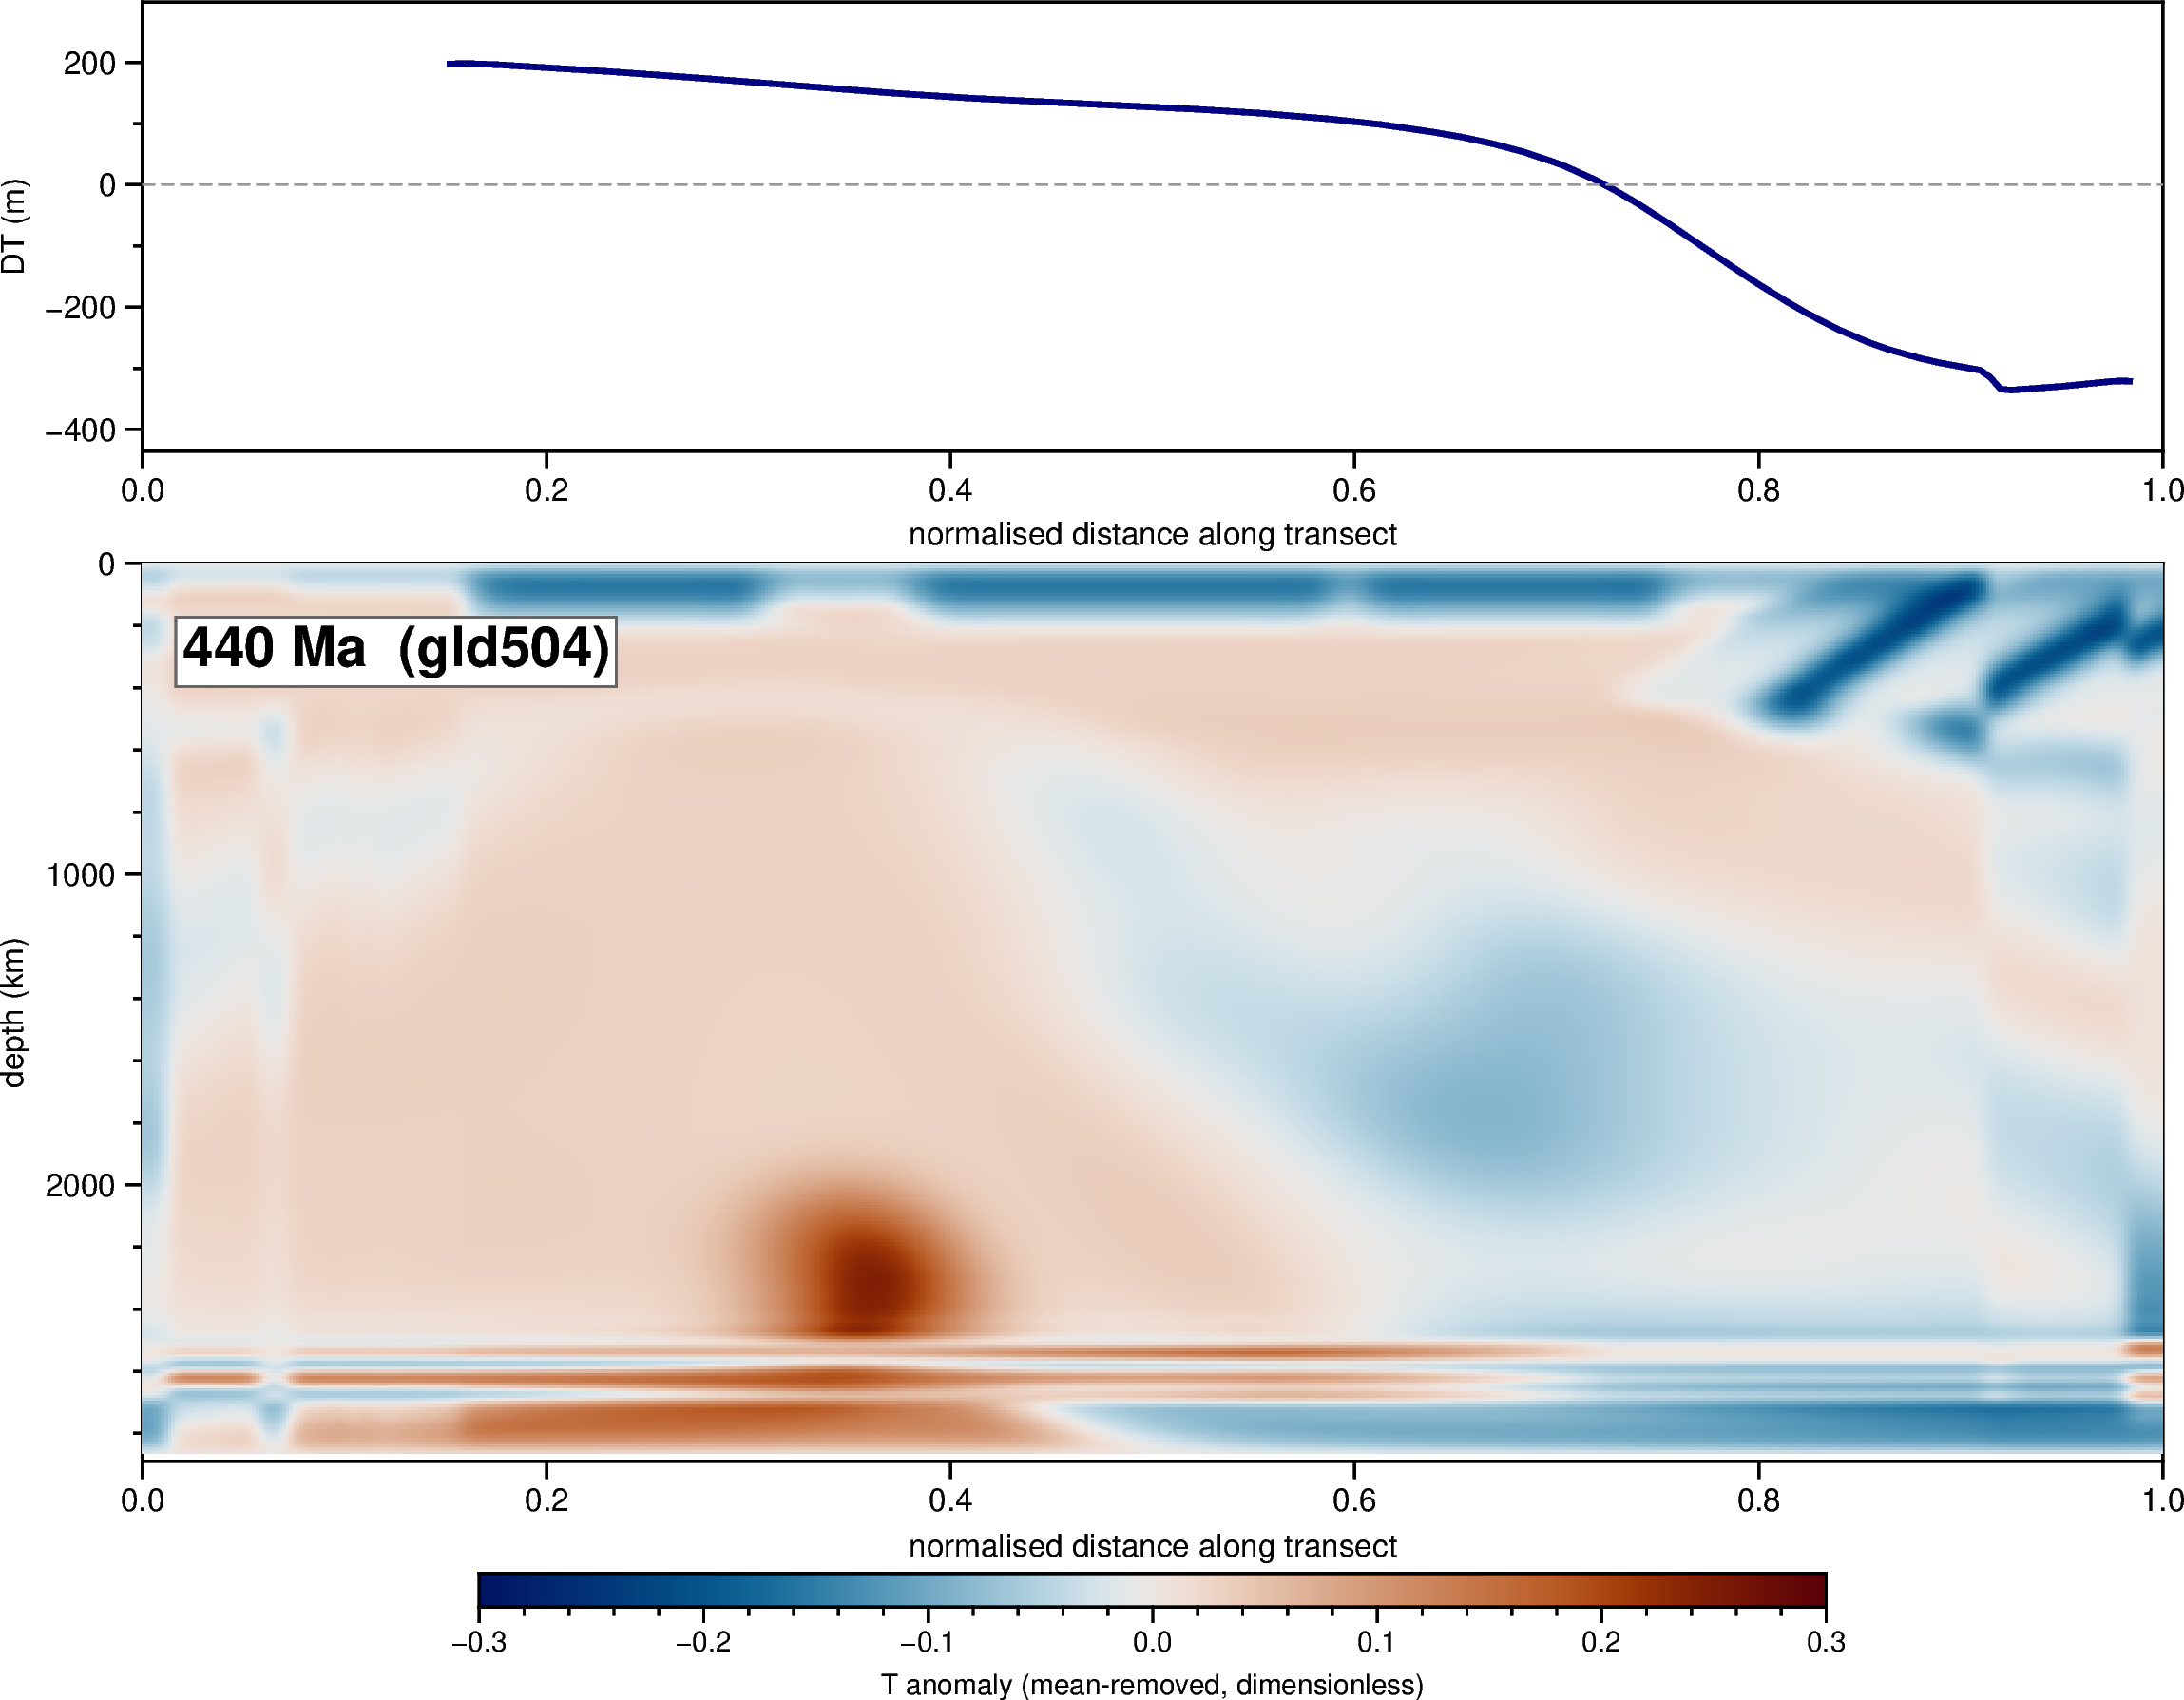

In [5]:
# Cell 4 — paired-panel renderer
# IMPORTANT — coordinate frames in this cell:
#   Mantle T cube (Santosh's gld504 .grd files): GLOBAL EARTH FRAME at
#     each age. Sample at RECONSTRUCTED transect coords (rlon, rlat).
#   DT cube (Santosh's PlateFrameGrid_LAU/ .nc files): PLATE FRAME for
#     Laurentia. Sample at PRESENT-DAY transect coords (tlon, tlat) —
#     because Laurentian points are fixed in plate-frame at all ages.
#
# Heatmap rendering uses dims renamed to ("y", "x") with x normalised
# to 0..1 along the transect so it lines up with the basemap region.

def render_snapshot(t_ma):
    rlon, rlat = reconstructed[t_ma]

    # --- Sample DT at present-day transect coords (PLATE FRAME) -----------
    dt_grid, dt_age_used = load_dt_at(t_ma)
    dt_line = dt_grid.interp(
        lon=xr.DataArray(tlon, dims="dist"),
        lat=xr.DataArray(tlat, dims="dist"),
    ).values
    n_dt_valid = int(np.isfinite(dt_line).sum())
    print(f"  t={t_ma:.0f} Ma  DT-sample valid points: {n_dt_valid}/{len(dt_line)}  "
          f"(DT file used = {dt_age_used} Ma)")

    # --- Sample the mantle T column at reconstructed coords (EARTH FRAME) -
    column = sample_mantle_along_transect(mantle, t_ma, rlon, rlat)
    # Renaming + re-coordinate: dims -> ("y", "x"); x -> normalised 0..1 so
    # the heatmap aligns with the basemap region of the lower panel.
    heatmap = (column
        .transpose("depth", "dist")
        .rename({"depth": "y", "dist": "x"})
        .assign_coords(x=np.linspace(0.0, 1.0, len(rlon))))

    # --- Regrid onto a UNIFORM depth axis (avoids grdimage rendering
    # each non-uniform row as a wide rectangle). Santosh's depth levels
    # go from ~15 km spacing at the surface to ~100 km spacing in the
    # deep mantle; without this regridding step the heatmap shows
    # spurious horizontal "blocks" that scale with the underlying
    # depth spacing — they have nothing to do with mantle structure.
    uniform_depths = np.linspace(0.0, 2890.0, 290)   # 10 km / pixel
    uniform_x = np.linspace(0.0, 1.0, 600)
    # CUBIC SPLINE along depth: linear interp produces a constant
    # gradient within each source-depth band and an abrupt gradient
    # change at the layer boundary; the human eye reads those gradient
    # discontinuities as visible "lines" even when absolute values are
    # continuous. Cubic spline gives a continuously-differentiable
    # profile, eliminating the band lines. Linear along x is fine
    # (transect was already uniformly sampled).
    heatmap = heatmap.interp(y=uniform_depths, method="cubic")
    heatmap = heatmap.interp(x=uniform_x,      method="linear")
    # Tiny 2D Gaussian smooth softens any remaining discretization
    # artefacts without erasing mantle structure (σ < grid spacing).
    smoothed = gaussian_filter(np.nan_to_num(heatmap.values, nan=0.0),
                               sigma=(1.5, 2.5))
    # Restore NaN mask
    nan_mask = ~np.isfinite(heatmap.values)
    smoothed[nan_mask] = np.nan
    heatmap = xr.DataArray(smoothed, coords=heatmap.coords, dims=heatmap.dims)
    n_mt_valid = int(np.isfinite(heatmap.values).sum())
    print(f"  mantle T-sample valid cells: {n_mt_valid}/{heatmap.size}  "
          f"(range {float(np.nanmin(heatmap.values)):+.2f}..{float(np.nanmax(heatmap.values)):+.2f})")

    fig = pygmt.Figure()

    # --- Upper panel — dynamic topography along the surface transect ---
    if np.any(np.isfinite(dt_line)):
        dt_min = float(np.nanmin(dt_line))
        dt_max = float(np.nanmax(dt_line))
    else:
        dt_min, dt_max = -1000.0, 1500.0
    yrange = (min(-200.0, dt_min - 100), max(200.0, dt_max + 100))
    fig.basemap(region=[0, 1, *yrange], projection="X18c/4c",
                frame=["xa0.2+lnormalised distance along transect",
                       "yaf+lDT (m)", "WSrt"])
    if np.any(np.isfinite(dt_line)):
        fig.plot(x=np.linspace(0, 1, len(dt_line)),
                 y=dt_line, pen="1.5p,navy")
    fig.plot(x=[0, 1], y=[0, 0], pen="0.4p,gray60,--")

    fig.shift_origin(yshift="-9c")

    # --- Lower panel — mantle T anomaly column (mean-removed, dimensionless)
    # Continuous colormap with 600 levels (0.001 step) instead of
    # 60 levels (0.01 step). Slowly-varying anomalies stop
    # resolving as flat-coloured horizontal "isobar" bands.
    pygmt.makecpt(cmap="vik", series=[-0.3, 0.3, 0.001],
                  background="o", continuous=True)
    fig.basemap(region=[0, 1, 0, 2890], projection="X18c/-8c",
                frame=["xa0.2+lnormalised distance along transect",
                       "yaf+ldepth (km)", "WSrt"])
    fig.grdimage(grid=heatmap, cmap=True, nan_transparent=True)
    fig.colorbar(frame="af+lT anomaly (mean-removed, dimensionless)",
                 position="JBC+w12c/0.3c+h+o0/1c")

    fig.text(text=f"{t_ma:.0f} Ma  ({MODEL_NAME})",
             x=0.02, y=200, justify="TL",
             font="14p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40", no_clip=True)
    fig.show(width=900)
    display(HTML('<div style="height:1cm"></div>'))


for t in SNAPSHOT_TIMES:
    render_snapshot(t)


## What the figure shows

Two stacked panels for the chosen great-circle transect at `t_ma` Ma:

- **Top (1-D line) — dynamic topography (DT) along the transect**, in km, sampled from Santosh's plate-frame DT grid at the chosen age. Positive DT marks regions of long-wavelength uplift from a mantle plume or upwelling below; negative DT marks downwelling-driven subsidence. The dashed gray zero-deformation reference is included as a baseline for reading the amplitude.
- **Bottom (depth-vs-distance heatmap) — mean-removed mantle temperature anomaly** beneath the transect, from the surface down to ~2890 km depth. Hot anomalies (red) trace plumes rising through the mantle; cold anomalies (blue) trace slabs sinking from past subduction. The colourbar is in dimensionless mean-removed units; the colour scale spans ±0.3 (default in CONFIG).

The two panels share a horizontal axis (normalised distance 0–1 along the transect), so a feature in the deep mantle below a given distance is visually aligned with its surface DT signature above. A hot column from the lower mantle to the surface aligned with a positive DT bump is the canonical "plume-uplift" signature in this kind of diagram.


## Extend this

- **Animate.** Loop over all times in the mantle cube and stitch frames with ffmpeg (recipe in T06). The 920–0 Ma animation is one of the main supplementary videos in Dhungana & Flament's paper.
- **Swap the mantle model.** Repoint `the Temperature/ and PlateFrameGrid_LAU/ directories under SANTOSH_REPO` at one of the other Dhungana & Flament suite-mate models (Müller 2019, Cao 2024 with Merdith kinematics, etc.). The notebook does not depend on Müller 2019 specifically.
- **Different transect.** Set `TRANSECT_START` / `TRANSECT_END` to cross Gondwana, Baltica, or East Asia and see how the mantle structure beneath those cratons evolved.
- **Cross-reference T17.** T17 uses present-day tomography with reconstructed boundaries; T18 uses paleo-mantle with reconstructed surface points. Plotting both for the same craton through 200 Ma highlights what is observed vs predicted in the deep mantle.

## References

- Dhungana, S. & Flament, N. (2025). The deep Earth origin of the Great Unconformity. *Journal of Geophysical Research — Solid Earth* (in press). https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity
- Müller, R.D. et al. (2019). A tectonic-rules-based mantle reference frame since 1 billion years ago. *Solid Earth* 13, 1127–1159.
- Cao, X. et al. (2024). A deep-time Phanerozoic to Proterozoic plate motion model. *ESSD* 16, 4007–4032.
- Mather, B.R. et al. (2024). GPlately. *Geoscience Data Journal* 11, 3–10.
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Tong, J.-H., Ngo, L., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J. & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.10578540
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515
- Chin, M., Mather, B.R. & Müller, R.D. (2024). Plate Model Manager: A Python package for downloading and managing plate reconstruction models. *Journal of Open Source Software* 9(101), 7090. https://doi.org/10.21105/joss.07090
